In [1]:
#load data
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

# For hyperparameter tuning (Optuna is optional, we'll use GridSearch for simplicity)

import warnings
warnings.filterwarnings('ignore')
dataset = pd.read_csv("dataset/Crop_recommendation.csv")

In [2]:
print(dataset.head())
dataset.info()
print(dataset.shape) #we already know that
dataset.describe()#all values seem fine

    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB
(2200, 8)


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [3]:
dataset.isnull().sum() #outputs 00000000 so dataset is probably pre-curated
#dataset = dataset.dropna() #drops rows with N/A wont do anything here
#or better df.fillna(df.mean(), inplace=True) #fills missing numeric values with column mean affaects data credibility


N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [4]:
# To see how many total duplicates you have
print(dataset.duplicated().sum())

# To see the actual duplicate rows
print(dataset[dataset.duplicated()])

0
Empty DataFrame
Columns: [N, P, K, temperature, humidity, ph, rainfall, label]
Index: []


In [5]:
print(dataset['label'].nunique())#how many fruit types
print(dataset['label'].unique())#how many unique fruit types
print(dataset['label'].value_counts()) # how many of the fruits are there
print(dataset['label'].value_counts(normalize=True))

22
<StringArray>
[       'rice',       'maize',    'chickpea', 'kidneybeans',  'pigeonpeas',
   'mothbeans',    'mungbean',   'blackgram',      'lentil', 'pomegranate',
      'banana',       'mango',      'grapes',  'watermelon',   'muskmelon',
       'apple',      'orange',      'papaya',     'coconut',      'cotton',
        'jute',      'coffee']
Length: 22, dtype: str
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64
label
rice           0.045455
maize          0.045455
chickpea       0.045455
kidneybeans    0.045455
pigeonpeas     0.045455
mothbeans      0.045455
mungbean       0.045455
b

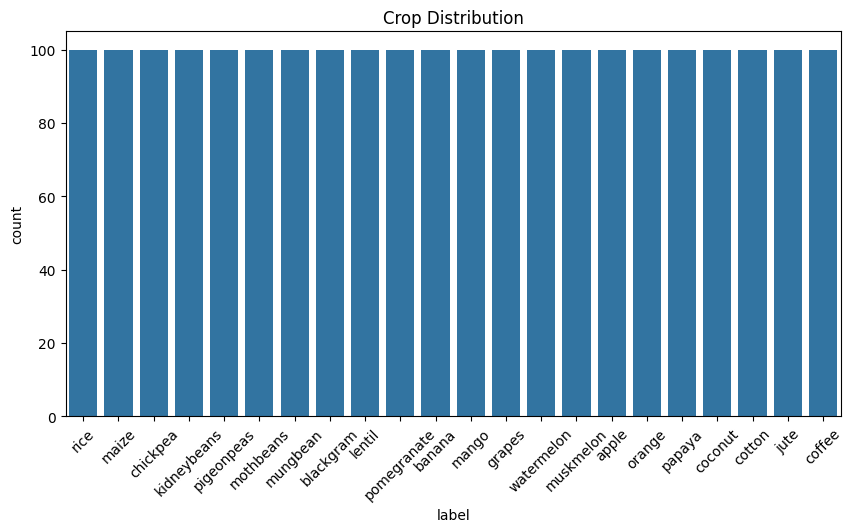

In [6]:
#dataset["label"].value_counts
#looks better:
plt.figure(figsize=(10,5))  # # sets graph size

sns.countplot(x="label", data=dataset)  # # automatically counts each crop

plt.title("Crop Distribution")  # # chart title
plt.xticks(rotation=45)  # # rotates labels
plt.show()  # # displays graph

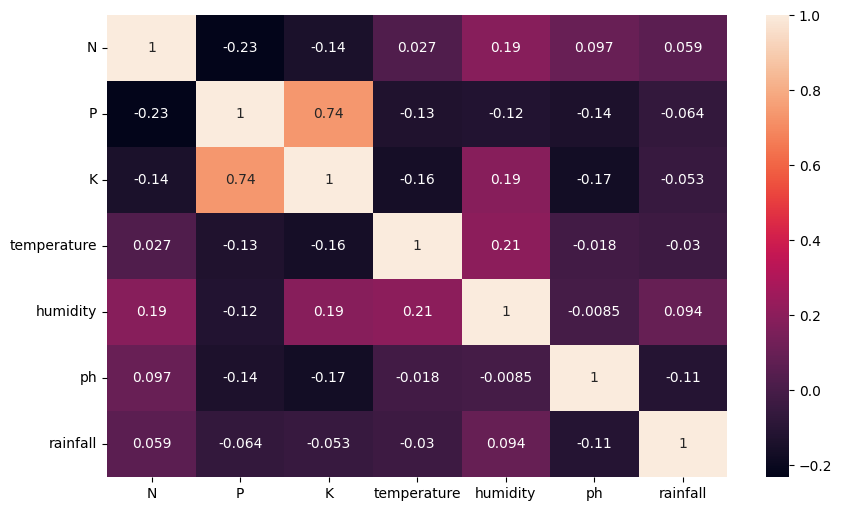

In [7]:
plt.figure(figsize=(10,6))  # # sets figure size
sns.heatmap(dataset.corr(numeric_only=True), annot=True)  # # shows correlation between features
plt.show()  # # displays plot

we see high correlation between pottasium (k) and phosphore (P ,likely because fertilisers contain multiple ingredients as to kee the soil balanced ) 

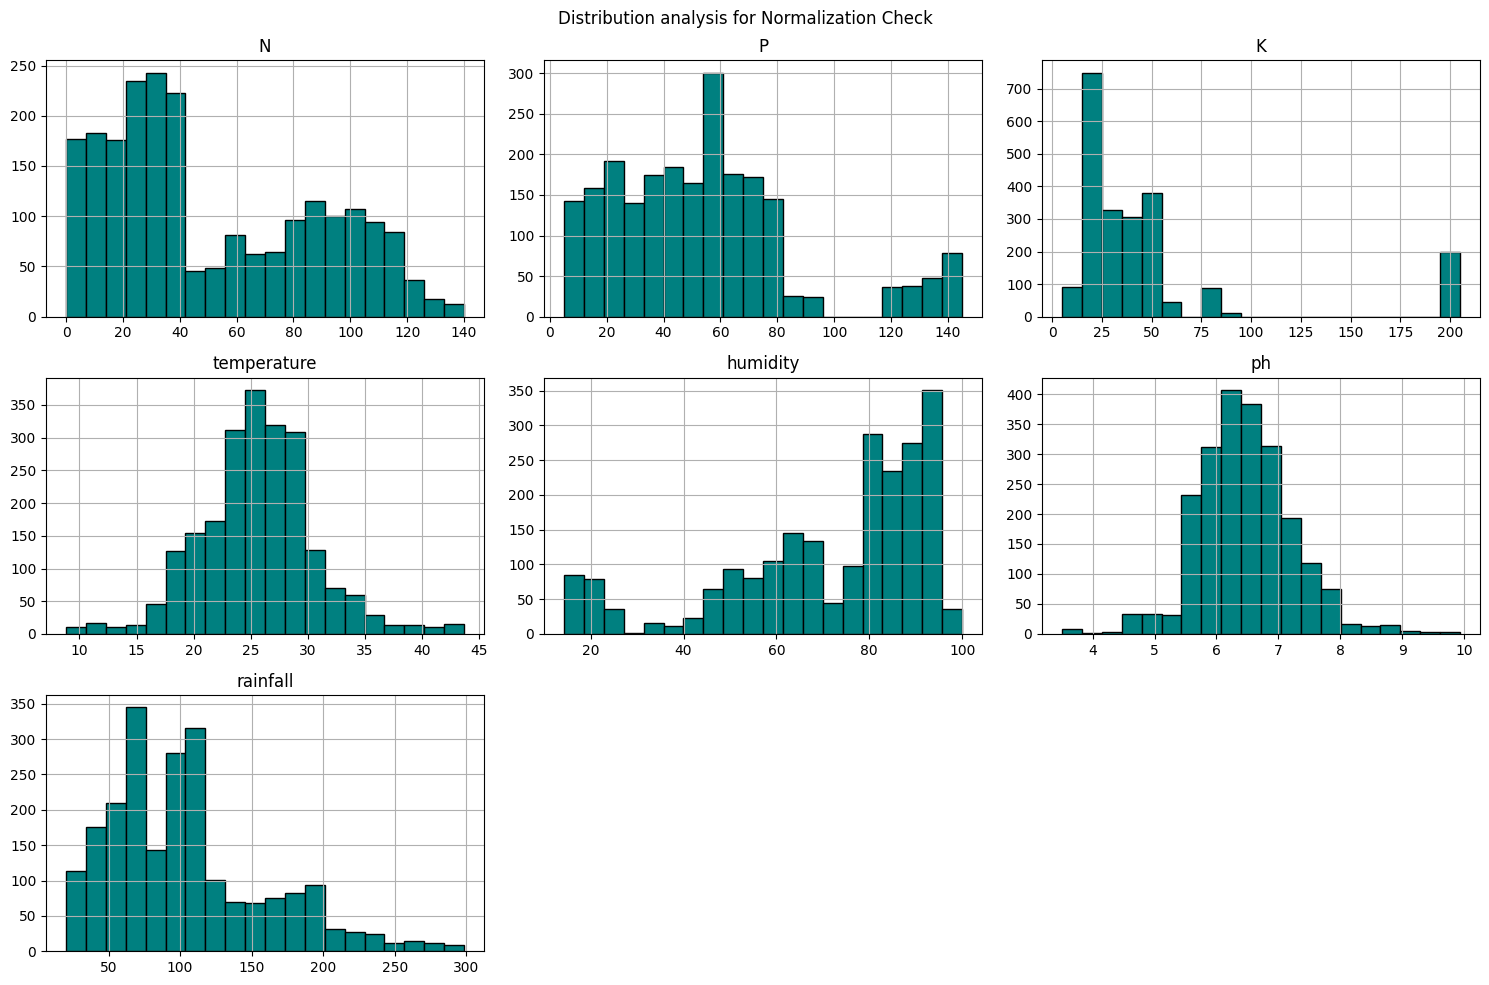

In [8]:
import matplotlib.pyplot as plt

# List of numerical features
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

# Create a figure with subplots
dataset[features].hist(bins=20, figsize=(15, 10), layout=(3, 3), color='teal', edgecolor='black')

plt.suptitle("Distribution analysis for Normalization Check")
plt.tight_layout()
plt.show()

N                0
P              138
K              200
temperature     86
humidity        30
ph              57
rainfall       100
dtype: int64


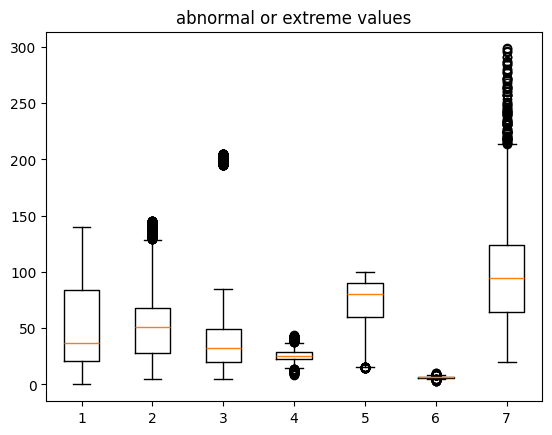

In [9]:
#outlier detection
numc = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
num = dataset[numc]
Q1 = num.quantile(0.25)  # # first quartile
Q3 = num.quantile(0.75)  # # third quartile
IQR = Q3 - Q1  # # interquartile range

outliers = ((num < (Q1 - 1.5 * IQR)) | (num > (Q3 + 1.5 * IQR))).sum()  # # counts outliers per column
print(outliers)  # # shows outlier counts

plt.boxplot(num)
plt.title("abnormal or extreme values")
plt.show()

###################################################################################################################################

In [10]:
# This turns the single 'label' column into many columns (one for each crop)
X = dataset.drop("label", axis=1)
#Y = pd.get_dummies(dataset['label'] , dtype=int) #one hot encoding
Y = dataset['label']
Y.head()




0    rice
1    rice
2    rice
3    rice
4    rice
Name: label, dtype: str

In [11]:
#encode labels into "encoded_dataset" variable
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
encoded_dataset = dataset.copy()
encoded_dataset['label'] = le.fit_transform(encoded_dataset['label'])
print(encoded_dataset.head())


    N   P   K  temperature   humidity        ph    rainfall  label
0  90  42  43    20.879744  82.002744  6.502985  202.935536     20
1  85  58  41    21.770462  80.319644  7.038096  226.655537     20
2  60  55  44    23.004459  82.320763  7.840207  263.964248     20
3  74  35  40    26.491096  80.158363  6.980401  242.864034     20
4  78  42  42    20.130175  81.604873  7.628473  262.717340     20


In [12]:
# Normalization step removed — keeping original feature values
features = encoded_dataset.drop("label", axis=1).columns
print("Feature means (unnormalized):", encoded_dataset[features].mean().round(4).tolist())
print("Feature stds (unnormalized):", encoded_dataset[features].std(ddof=0).round(4).tolist())
encoded_dataset.head()


Feature means (unnormalized): [50.5518, 53.3627, 48.1491, 25.6162, 71.4818, 6.4695, 103.4637]
Feature stds (unnormalized): [36.9089, 32.9784, 50.6364, 5.0626, 22.2588, 0.7738, 54.9459]


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,20
1,85,58,41,21.770462,80.319644,7.038096,226.655537,20
2,60,55,44,23.004459,82.320763,7.840207,263.964248,20
3,74,35,40,26.491096,80.158363,6.980401,242.864034,20
4,78,42,42,20.130175,81.604873,7.628473,262.717340,20


In [13]:
#train 5 models on the encoded dataset and evaluate their performance,with stratifying to maintain class distribution in train and test sets
X = encoded_dataset.drop("label", axis=1)
Y = encoded_dataset['label']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
models = {
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}
for name, model in models.items():
    model.fit(X_train, Y_train)
    Y_pred = model.predict(X_test)
    print(f"{name} Accuracy: {accuracy_score(Y_test, Y_pred):.4f}")
    print(classification_report(Y_test, Y_pred))


Random Forest Accuracy: 0.9955
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.95      0.97        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.00       

XGboost Wins with 0.9932 accuracy

In [14]:
#saving xgboost model as "xgboost_model.pkl"
joblib.dump(models["XGBoost"], "xgboost_model.pkl")

['xgboost_model.pkl']

In [ ]:
#using grid search to find best hyperparameters for all 5 models then find the best model based on accuracy score and classification report

# Define Random Forest parameter grid
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "bootstrap": [True, False]
}

param_grids = {
    "Random Forest": param_grid_rf,
    "Gradient Boosting": {
        "n_estimators": [100, 200],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 5],
        "subsample": [0.8, 1.0]
    },
    "Logistic Regression": {
        "C": [0.1, 1, 10],
        "solver": ["lbfgs"],
        "penalty": ["l2"],
        "max_iter": [1000]
    },
    "SVM": {
        "C": [0.1, 1, 10],
        "kernel": ["rbf", "linear"],
        "gamma": ["scale", "auto"]
    },
    "XGBoost": {
        "n_estimators": [100, 200],
        "max_depth": [3, 5],
        "learning_rate": [0.05, 0.1],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    }
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_models = {}
test_scores = {}

for name, model in models.items():
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        scoring="accuracy",
        cv=cv,
        n_jobs=-1,
        verbose=1
    )
    grid.fit(X_train, Y_train)
    best_models[name] = grid.best_estimator_

    Y_pred = best_models[name].predict(X_test)
    acc = accuracy_score(Y_test, Y_pred)
    test_scores[name] = acc

    print(f"\n{name} best params: {grid.best_params_}")
    print(f"{name} test accuracy: {acc:.4f}")
    print(classification_report(Y_test, Y_pred))

best_name = max(test_scores, key=test_scores.get)
print(f"\nBest model: {best_name} with accuracy {test_scores[best_name]:.4f}")
best_model = best_models[best_name]


NameError: name 'param_grid_rf' is not defined

In [ ]:
#compare Best model: Random Forest with accuracy 0.9932 withe xgboost_model.pkl which has accuracy 0.9922
xgb_loaded = joblib.load("xgboost_model.pkl")

rf_preds = best_model.predict(X_test)
xgb_preds = xgb_loaded.predict(X_test)

rf_acc = accuracy_score(Y_test, rf_preds)
xgb_acc = accuracy_score(Y_test, xgb_preds)

print("Random Forest test accuracy:", rf_acc)
print("XGBoost loaded from file test accuracy:", xgb_acc)

print("\nRandom Forest classification report:")
print(classification_report(Y_test, rf_preds))

print("XGBoost classification report:")
print(classification_report(Y_test, xgb_preds))

comparison = pd.DataFrame({
    "model": ["Random Forest", "XGBoost (loaded)"],
    "accuracy": [rf_acc, xgb_acc]
})
display(comparison)

XGBoost test accuracy: 0.9932
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      0.90      0.95        20
          11       1.00      1.00      1.00        20
          12       1.00      1.00      1.00        20
          13       0.95      1.00      0.98        20
          14       0.95      1.00      0.98        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.00        